# Comparer les dépenses et le capital restant

Ce parcours commence par un calcul que l’on peut vérifier à la main, puis lit les résultats du projet. Il n’exécute aucun téléchargement. Les analyses complètes se lancent avec la commande `rnv run`.

In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

if not Path("config/protocol.json").exists():
    os.chdir("..")
assert Path("config/protocol.json").exists(), "Ouvrir ce notebook dans le dépôt"

## Un exemple à vérifier à la main

In [2]:
from rnv.model import Policy, simulate

policy = Policy(initial=100, rate=0.1, fee=0)
for returns in [[-0.20, 0.25], [0.25, -0.20]]:
    paid, wealth, _ = simulate(returns, [0, 0], "fixed", policy)
    print(returns, "dépenses", paid[0].tolist(), "capital final", round(wealth[0, -1], 2))

[-0.2, 0.25] dépenses [10.0, 10.0] capital final 77.5
[0.25, -0.2] dépenses [10.0, 10.0] capital final 82.0


L’ordre des rendements change le solde malgré un rendement composé identique. Le retrait payé entre les deux années explique la différence.

## Les observations de l’étude

Les colonnes et leurs unités sont expliquées dans [le guide des résultats](../docs/RESULTATS.md). Les proportions sont enregistrées en fractions. Une valeur de 0,10 signifie 10 %.

In [3]:
results = pd.read_csv("results/tables/historical_summary.csv")
results.head(12)

,horizon,rule,paths,ruin_share,unfunded_share,below_budget_share,years_below_mean,longest_shortfall_p95,shortfall_fraction_mean,mean_spending_median,minimum_spending_p05,terminal_wealth_median
0,30,fixed,120,0.050000,0.050000,0.050000,0.150000,0.05,0.003837,40000.000000,39386.329609,9.343102e+05
1,30,percentage,120,0.000000,0.000000,0.558333,4.700000,15.00,0.028803,44174.496630,15947.710007,1.073733e+06
2,30,dynamic,120,0.000000,0.000000,0.175000,1.050000,8.10,0.001757,46711.501226,27412.693336,8.575587e+05
3,30,floor,120,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,46711.501226,30000.000000,8.575587e+05
4,40,fixed,110,0.190909,0.190909,0.190909,1.345455,10.55,0.031429,40000.000000,0.000000,8.125966e+05
5,40,percentage,110,0.000000,0.000000,0.745455,6.790909,15.00,0.029469,41302.402306,15918.730054,1.058295e+06
6,40,dynamic,110,0.000000,0.000000,0.272727,3.272727,19.10,0.007883,44867.697790,23440.284157,4.991311e+05
7,40,floor,110,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,44867.697790,30000.000000,4.974183e+05
8,50,fixed,100,0.320000,0.320000,0.320000,4.090000,21.00,0.079546,40000.000000,0.000000,8.984622e+05
9,50,percentage,100,0.000000,0.000000,0.910000,8.660000,16.00,0.029878,41092.483478,15459.011517,1.056664e+06


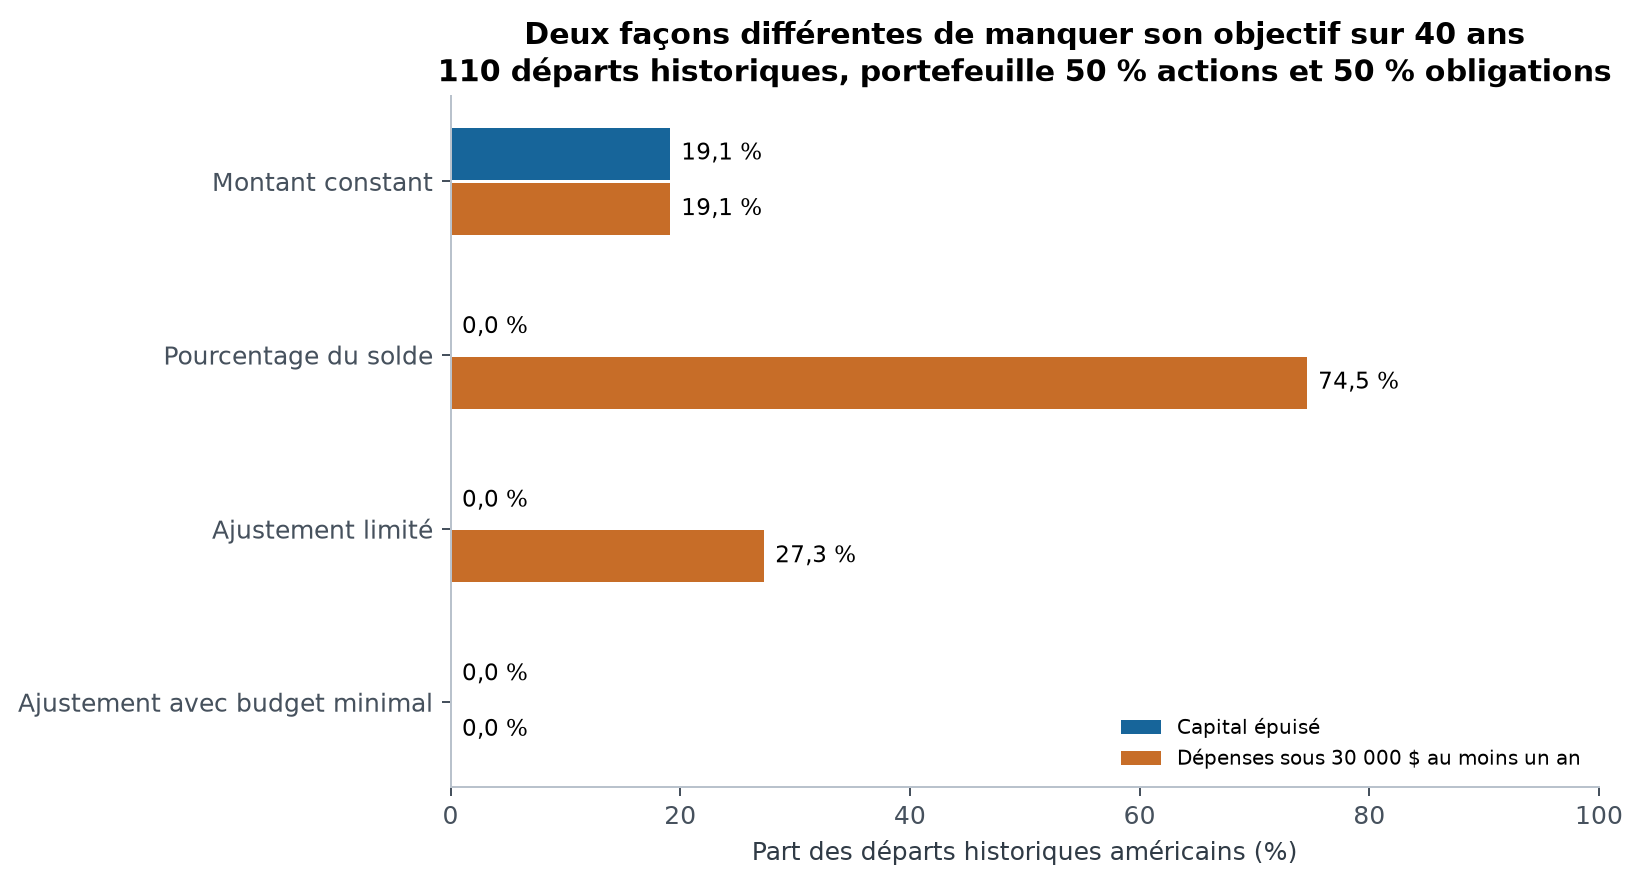

In [4]:
display(Image(filename="results/figures/budget_et_capital.png", width=900))

## Vérifier une autre hypothèse

Le tableau suivant montre une analyse complémentaire. Comparer les périodes, les dénominateurs et les paramètres avant de comparer les résultats.

In [5]:
pd.read_csv("results/tables/bootstrap_summary.csv").head(18)

,block_years,horizon,rule,paths,ruin_share,unfunded_share,below_budget_share,years_below_mean,longest_shortfall_p95,shortfall_fraction_mean,mean_spending_median,minimum_spending_p05,terminal_wealth_median
0,3,30,fixed,10000,0.0677,0.0677,0.0658,0.3849,3,0.011973,40000.000000,0.000000,1.508632e+06
1,3,30,percentage,10000,0.0000,0.0000,0.3810,3.7891,18,0.025646,47286.558171,16235.446712,1.229120e+06
2,3,30,dynamic,10000,0.0325,0.0325,0.1327,0.8876,9,0.006759,48542.543605,25805.404781,1.133092e+06
3,3,30,floor,10000,0.0339,0.0339,0.0337,0.1819,0,0.005533,48542.543605,30000.000000,1.133092e+06
4,3,40,fixed,10000,0.1455,0.1455,0.1436,1.4853,13,0.035776,40000.000000,0.000000,1.882800e+06
5,3,40,percentage,10000,0.0000,0.0000,0.4236,5.5768,26,0.031381,49147.776588,14153.982418,1.316261e+06
6,3,40,dynamic,10000,0.0928,0.0928,0.2103,2.4918,19,0.023109,50292.649840,0.000000,1.113508e+06
7,3,40,floor,10000,0.1009,0.1009,0.1003,0.8661,7,0.020483,50292.649840,0.000000,1.112524e+06
8,3,50,fixed,10000,0.2056,0.2056,0.2046,3.2738,23,0.063920,40000.000000,0.000000,2.428775e+06
9,3,50,percentage,10000,0.0000,0.0000,0.4562,7.4276,33,0.036165,51152.859580,12881.584289,1.390717e+06


## Ce que l’on peut conclure

Revenir à [l’article](../ARTICLE.md) pour lire les conclusions et les limites. Les exemples du notebook ne remplacent pas les contrôles de chronologie et d’incertitude du paquet. Le [protocole](../docs/PROTOCOLE.md) indique ce qui était fixé avant le calcul complet.